<a href="https://colab.research.google.com/github/ksaad20/Digital-Signal-Processing-Mathematics-to-Code-/blob/main/Chapter_10_IQ_Modulation_%26_Software_Defined_Radio_(SDR)ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Math: Analytic signals, Hilbert transform, complex baseband representation, and quadrature modulation.

The Project: Build a pure-software AM/FM radio receiver that demodulates raw IQ data streams.

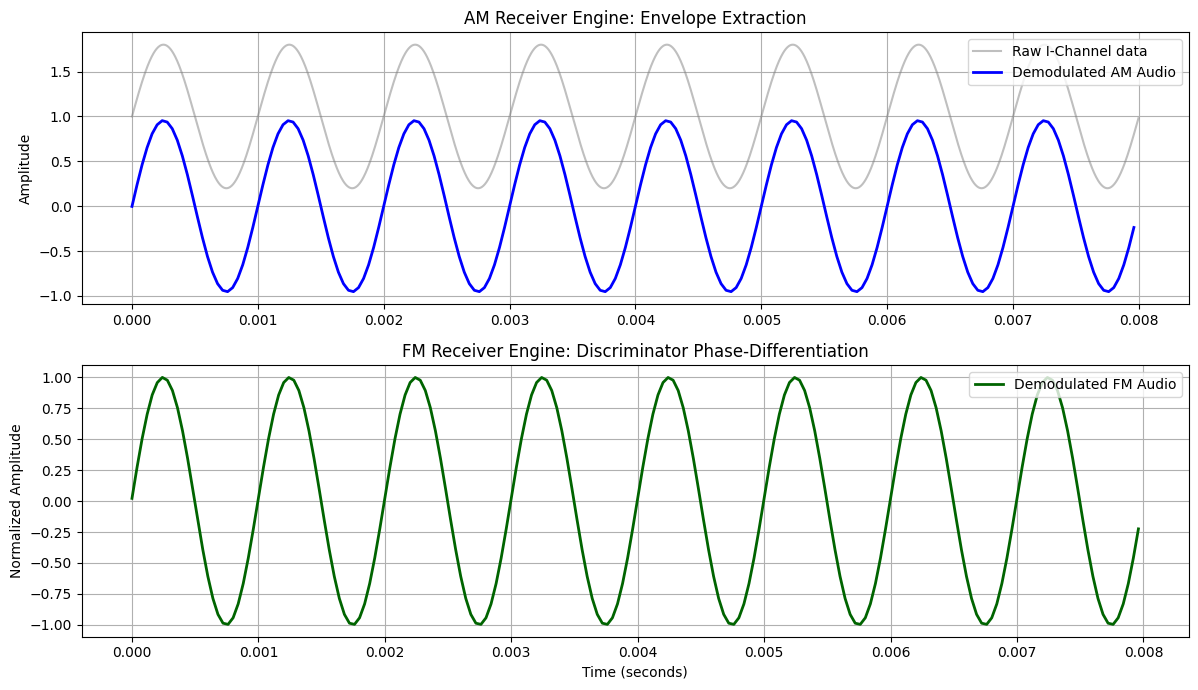

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

def am_demodulate(iq_data):
    """Demodulates a complex IQ stream containing Amplitude Modulation."""
    # Step 1: Extract the envelope (Magnitude)
    envelope = np.abs(iq_data)

    # Step 2: Remove the DC offset (AC coupling block)
    demodulated_audio = envelope - np.mean(envelope)
    return demodulated_audio

def fm_demodulate(iq_data):
    """Demodulates a complex IQ stream containing Frequency Modulation."""
    # Step 1: Multiply current sample by the complex conjugate of the previous sample
    # x[n] * conj(x[n-1]) = R[n]*R[n-1] * exp(j * (theta[n] - theta[n-1]))
    phase_diff = iq_data[1:] * np.conj(iq_data[:-1])

    # Step 2: Extract the angle of the resulting vector to get the frequency deviation
    demodulated_audio = np.angle(phase_diff)
    return demodulated_audio

# --- SYSTEM SIMULATION PIPELINE ---
fs_sdr = 250000  # SDR Sampling Rate (250 kHz I/Q bandwidth)
t = np.arange(0, 0.5, 1 / fs_sdr)

# 1. Synthesize a Mock Baseband Audio Message (1 kHz Tone)
f_message = 1000
audio_message = np.sin(2 * np.pi * f_message * t)

# 2. Synthesize AM IQ Stream
# AM Formula: IQ = (1 + m * message) * e^(j * 0)
am_modulation_index = 0.8
iq_am = (1.0 + am_modulation_index * audio_message) + 0j

# 3. Synthesize FM IQ Stream
# FM Formula: IQ = e^(j * 2 * pi * f_dev * integral(message))
fm_deviation = 25000 # 25 kHz frequency deviation swing
audio_integral = np.cumsum(audio_message) / fs_sdr
iq_fm = np.exp(1j * 2 * np.pi * fm_deviation * audio_integral)

# 4. Run the Pure Software Demodulators
recovered_am = am_demodulate(iq_am)
recovered_fm = fm_demodulate(iq_fm)

# 5. Downsample / Decimate to Audio Rates (e.g., ~10 kHz for visualization)
# In production, decimate 250kHz down to 48kHz for soundcard output
decimation_factor = 10
vis_am = signal.decimate(recovered_am, decimation_factor)
vis_fm = signal.decimate(recovered_fm, decimation_factor)
t_vis = t[::decimation_factor]

# --- VISUALIZATION MATRIX ---
plt.figure(figsize=(12, 7))

plt.subplot(2, 1, 1)
plt.plot(t[:2000], np.real(iq_am)[:2000], color='gray', alpha=0.5, label='Raw I-Channel data')
plt.plot(t_vis[:200], vis_am[:200] * 1.2, color='blue', linewidth=2, label='Demodulated AM Audio')
plt.title("AM Receiver Engine: Envelope Extraction")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc="upper right")

plt.subplot(2, 1, 2)
# Align timelines (FM extraction drops exactly 1 sample due to differentiation)
plt.plot(t_vis[:200], vis_fm[:200] / np.max(vis_fm), color='darkgreen', linewidth=2, label='Demodulated FM Audio')
plt.title("FM Receiver Engine: Discriminator Phase-Differentiation")
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.grid(True)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()